In [1]:
import numpy as np, pylab as plt
import importlib
import nbody2d_hidding
import cft

LCDM = nbody2d_hidding.Cosmology(68.0, 0.31, 0.69)
EdS = nbody2d_hidding.Cosmology(70.0, 1.0, 0.0)

In [14]:
N = 256
B_m = nbody2d_hidding.Box(2, N, 50.0)

A = 10
seed = 4
Power_spectrum = cft.Power_law(-0.5) * cft.Scale(B_m, 0.2) * cft.Cutoff(B_m)
phi = cft.garfield(B_m, Power_spectrum, cft.Potential(), seed) * A

force_box = cft.Box(2, N*2, B_m.L)
za = nbody2d_hidding.Zeldovich(B_m, force_box, EdS, phi)
initstate = za.state(0.02)
system = nbody2d_hidding.PoissonVlasov(force_box, EdS, za.particle_mass)
stepper = nbody2d_hidding.partial(nbody2d_hidding.leap_frog, 0.02, system)

finalstate = nbody2d_hidding.iterate_step(stepper, lambda s: s.time > 0.7, initstate)

In [15]:
x=finalstate.position[:,0].reshape(N,N)
y=finalstate.position[:,1].reshape(N,N)

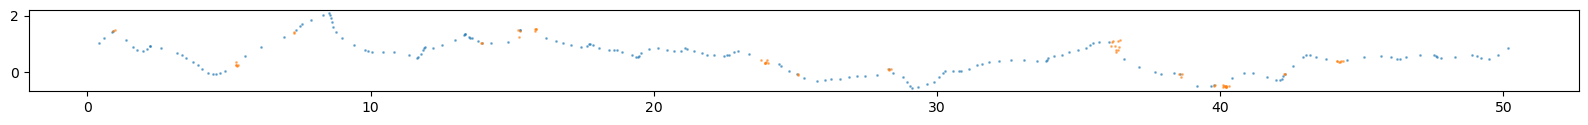

In [16]:
fig, ax = plt.subplots(figsize=(20,20))
ax.set_aspect('equal')
whereord=np.where(np.argsort(x[:,0]) == np.arange(N))
whereout = np.where(np.argsort(x[:,0]) != np.arange(N))
ax.scatter(x[whereord,0],y[whereord,0],s=1,alpha=0.5,c='C0')
ax.scatter(x[whereout,0],y[whereout,0],s=1,alpha=0.5,c='C1')

In [17]:
import origami2d, importlib
importlib.reload(origami2d)
mmax = origami2d.origami_order_tag(x,y,B_m.L)

In [18]:
print(mmax.shape)

(256, 256)


34323
17064
14149


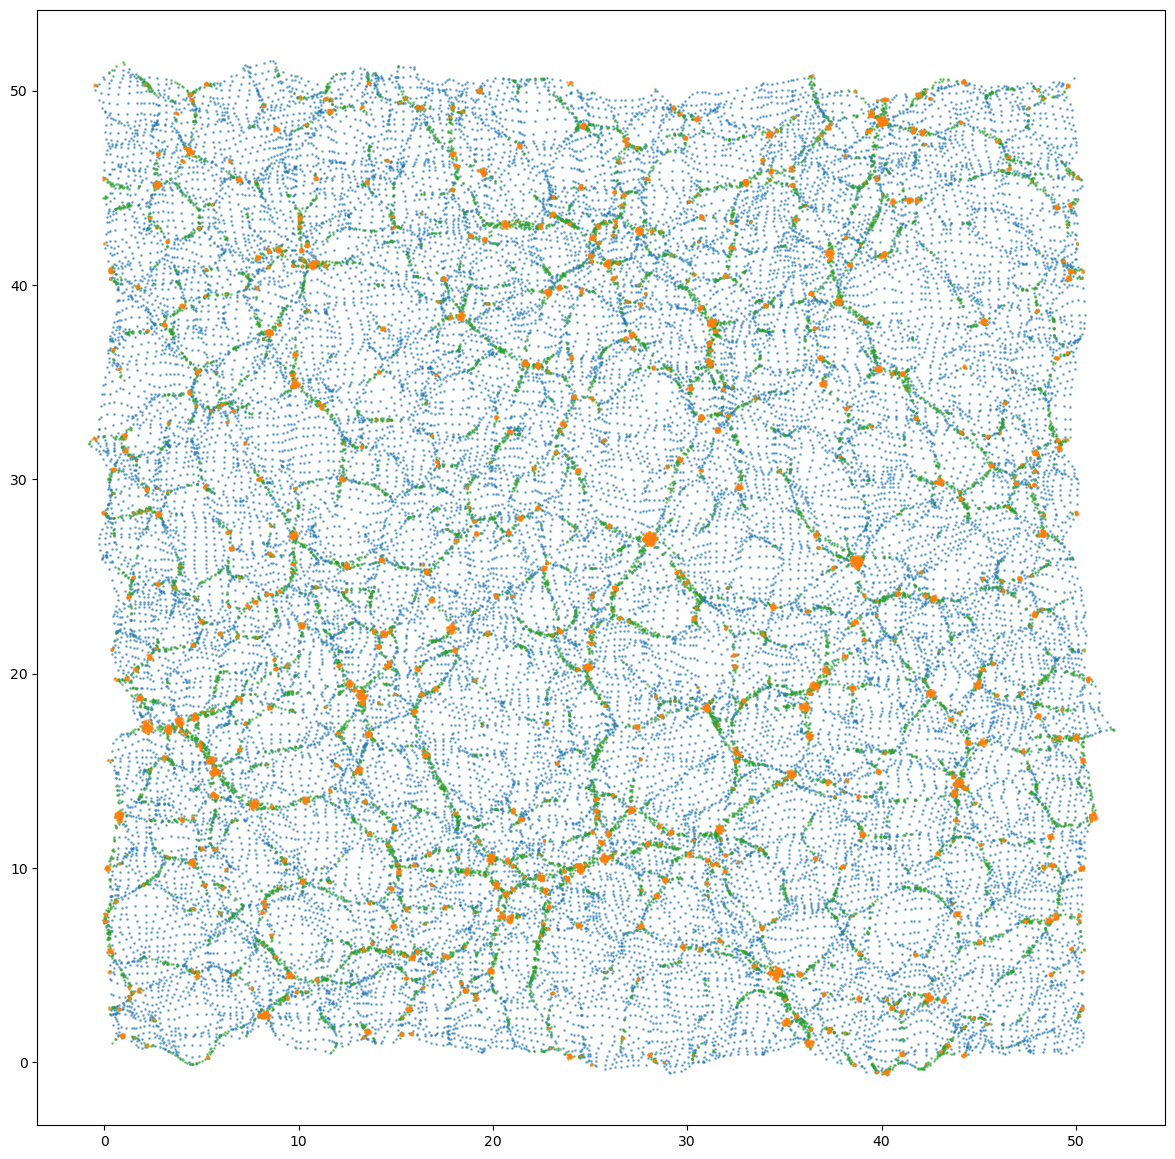

In [23]:
fig, ax = plt.subplots(figsize=(12,12))
border=0.03
plt.subplots_adjust(bottom=border,top=1-border,left=border,right=1-border)
ax.set_aspect('equal')
wherevoid = np.where(mmax.flat == 0)
wherephil = np.where(mmax.flat == 1)
wherenotnode = np.where(mmax.flat < 2)
wherenode = np.where(mmax.flat == 2)
print(len(wherevoid[0]))
print(len(wherephil[0]))
print(len(wherenode[0]))
plt.scatter(x.flat[wherevoid],y.flat[wherevoid],s=1,alpha=0.5)
plt.scatter(x.flat[wherephil],y.flat[wherephil],c='C2',s=1,alpha=0.5)
plt.scatter(x.flat[wherenode],y.flat[wherenode],c='C1',s=1,alpha=0.5)
plt.savefig('origami_example.png')

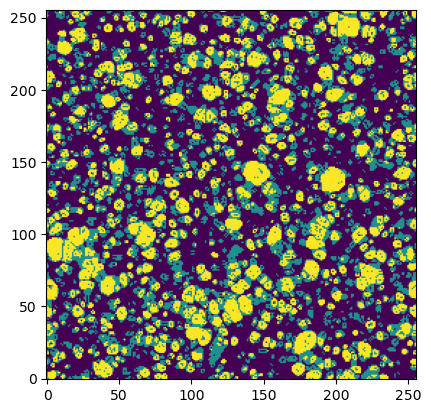

In [34]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
plt.imshow(mmax.T,origin='lower')
plt.savefig('lagrangian_morph_raw.png')

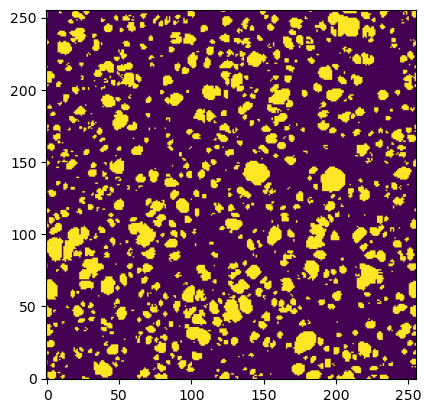

In [35]:
from skimage.morphology import remove_small_holes

msmallholes = remove_small_holes(mmax == 2)

fig, ax = plt.subplots()
ax.set_aspect('equal')
plt.imshow(msmallholes.astype(np.int8).T,origin='lower')
plt.savefig('lagrangian_haloes_holesfilled.png')

In [10]:
import scipy.ndimage as snd
groups = snd.label(msmallholes, structure=None, output=None)
initcentroids = np.zeros((groups[1],2),dtype=float)
for g in np.arange(0,groups[1]):
    wg=np.where(groups[0].flat == g)[0]
    initcentroids[g,:] = np.mean(initstate.position[wg,:], axis=0)

(256, 256)
0


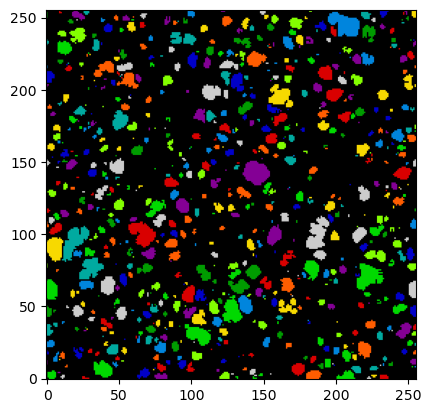

In [38]:
print(groups[0].shape)
plt.imshow((groups[0].T)%12,cmap='nipy_spectral',origin='lower')
print(groups[0][0,0])
plt.savefig('group_blobs.png')